&#x1f12f; Nicolás Daniel Rueda Araque - Digitalització 1r DAM/CIDE/25-26

In [ ]:
# Descomentar para actualizar librerias
# Si se actualiza alguna libreria hay que reiniciar el notebook
#!pip install pandas --upgrade --user --quiet
#!pip install numpy --upgrade --user --quiet
#!pip install scipy --upgrade --user --quiet
#!pip install scikit-learn --upgrade --user --quiet
#!pip install missingno --upgrade --user --quiet
# versionesmodernas pero compatibles con Colab
#!pip install "pandas==2.2.2" "numpy<2.1.0" scipy scikit-learn missingno --upgrade --quiet

In [48]:
# Librerías estándar de Python
import io
import warnings

# Manipulación de datos y visualización
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Herramientas de Scikit-Learn (Machine Learning)
from sklearn import datasets, set_config
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.manifold import LocallyLinearEmbedding, TSNE

# Entorno de Colab y gráficos 3D
from IPython.core.interactiveshell import InteractiveShell
from mpl_toolkits.mplot3d import Axes3D
from google.colab import files

# Configuraciones globales del Notebook
InteractiveShell.ast_node_interactivity = "all"

In [11]:



sns.set()

set_config(display='text')
warnings.filterwarnings('ignore')
pd.set_option('display.precision', 3)




# Ejercicio práctico de visualización

En este ejercicio trabajaremos con el conjunto de datos preprocesado en la primera sesion de laboratorio.

Encontraréis los datos preprocesados de Titanic entre el material de esta sesion (conjunto de entrenamiento), o podeis coger los datos que grabasteis en la sesión pasada.



Debéis aplicar los siguientes pasos:
- [ ] Aplicar PCA
- [ ] Gráfica de la varianza explicada por cada componente de PCA
- [ ] Representar los pesos de los componentes
- [ ] Visualizar los datos con PCA en 2/3D
- [ ] Aplicar LLE y visualizar los datos en 2/3D
- [ ] Aplicar t-SNE y visualizar los datos en 2/3D


**0. Preparación de datos**


In [13]:
# Importanción CSV desde drive
uploaded = files.upload()

Saving titanic.csv to titanic (1).csv


Objetivo: separar los mas de 1000 individuos en 6 clases en una matríz 3x3 según su clase y si sobrevivió



In [14]:
titanic_data = pd.read_csv("titanic.csv", header=0)
#leemos los datos

#renombramos algunas columnas para mejorar la legibilidad
titanic_data = titanic_data.rename(columns={'pclass':'socialClass', 'sibsp':'number of siblings', 'home.dest':'destination',})

#mapeamos los datos segun clase social y si sobrevivió
titanic_data['socialClass'] = titanic_data['socialClass'].map({1:'First', 2:'Second', 3:'Third'})
titanic_data['survived'] = titanic_data['survived'].map({1:'Yes', 0:'No'})

#mostramos los datos
titanic_data.describe(include='all')
titanic_data.head()

,socialClass,survived,name,sex,age,number of siblings,parch,ticket,fare,cabin,embarked,boat,body,destination
count,1309,1309,1309,1309,1046.000,1309.000,1309.000,1309,1308.000,295,1307,486,121.000,745
unique,3,2,1307,2,NaN,NaN,NaN,929,NaN,186,3,27,NaN,369
top,Third,No,"Kelly, Mr. James",male,NaN,NaN,NaN,CA. 2343,NaN,C23 C25 C27,S,13,NaN,"New York, NY"
freq,709,809,2,843,NaN,NaN,NaN,11,NaN,6,914,39,NaN,64
mean,NaN,NaN,NaN,NaN,29.881,0.499,0.385,NaN,33.295,NaN,NaN,NaN,160.810,NaN
std,NaN,NaN,NaN,NaN,14.413,1.042,0.866,NaN,51.759,NaN,NaN,NaN,97.697,NaN
min,NaN,NaN,NaN,NaN,0.167,0.000,0.000,NaN,0.000,NaN,NaN,NaN,1.000,NaN
25%,NaN,NaN,NaN,NaN,21.000,0.000,0.000,NaN,7.896,NaN,NaN,NaN,72.000,NaN
50%,NaN,NaN,NaN,NaN,28.000,0.000,0.000,NaN,14.454,NaN,NaN,NaN,155.000,NaN
75%,NaN,NaN,NaN,NaN,39.000,1.000,0.000,NaN,31.275,NaN,NaN,NaN,256.000,NaN


,socialClass,survived,name,sex,age,number of siblings,parch,ticket,fare,cabin,embarked,boat,body,destination
0,First,Yes,"Allen, Miss. Elisabeth Walton",female,29.000,0,0,24160,211.338,B5,S,2,NaN,"St Louis, MO"
1,First,Yes,"Allison, Master. Hudson Trevor",male,0.917,1,2,113781,151.550,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,First,No,"Allison, Miss. Helen Loraine",female,2.000,1,2,113781,151.550,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,First,No,"Allison, Mr. Hudson Joshua Creighton",male,30.000,1,2,113781,151.550,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,First,No,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.000,1,2,113781,151.550,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [15]:
#definimos una columna igual a la clase social + si ha sobrevivido
titanic_data['class'] =  titanic_data.socialClass + " " + titanic_data.survived
# segunda columna gual al valor total + ordenar por indíce
titanic_data['class'].value_counts().sort_index()

,count
class,
First No,123
First Yes,200
Second No,158
Second Yes,119
Third No,528
Third Yes,181


<Axes: xlabel='value', ylabel='variable'>

<Axes: xlabel='value', ylabel='variable'>

Text(0.5, 1.0, 'Distribución de Edad y Tarifa por Clase Social y Supervivencia')

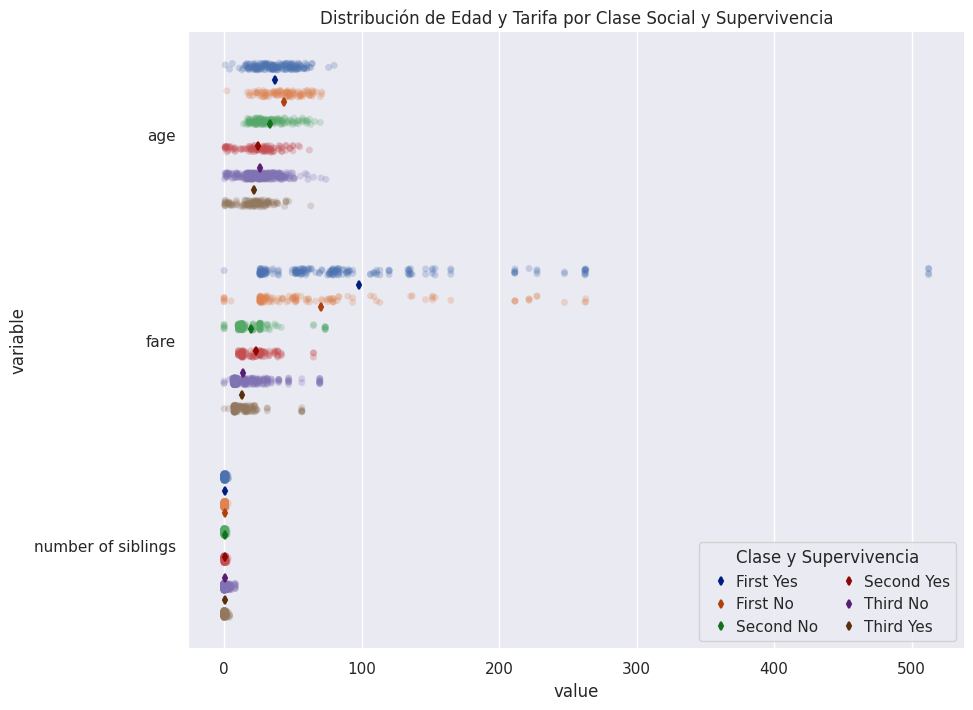

In [23]:

# Seleccionamos las variables numéricas que queremos comparar
#en este caso edad, tarifa y numero de familiares en el mismo trayecto
titanic_num_vars = ['age', 'fare', 'number of siblings']

# "Derretimos" el DataFrame para Seaborn (transformar los datos de un foramto de muchas columnas a uno de muchas filas)
df_titanic_melt = pd.melt(titanic_data, id_vars=['class'], value_vars=titanic_num_vars)

#Creación del gráfico
f, ax = plt.subplots(figsize=(10, 8))
sns.despine(bottom=True, left=True)

# Dibujamos los puntos
sns.stripplot(x="value", y="variable", hue="class", data=df_titanic_melt,
              dodge=True, alpha=.25, zorder=1)

# Dibujamos el punto medio y el intervalo
sns.pointplot(x="value", y="variable", hue="class", data=df_titanic_melt,
              dodge=.8 - .8 / 3, join=False, palette="dark",
              markers="d", scale=.75, ci=None)

# leyenda
handles, labels = ax.get_legend_handles_labels()
# En el Titanic hay 6 clases
# Por eso ajustamos el índice de la leyenda para que no se duplique
ax.legend(handles[6:], labels[6:], title="Clase y Supervivencia",
          handletextpad=0, columnspacing=1, loc="lower right", ncol=2, frameon=True)

plt.title("Distribución de Edad y Tarifa por Clase Social y Supervivencia")
plt.show()

# Cada puntito pequeño y semi-transparente es un pasajero real del Titanic
# El punto medio representa la Media (Promedio).
# La línea representa el intervalo y/o dispersión de datos

Exploración básica de los datos

In [26]:
# Cargamos las columnas con datos más interesantes y de los cuales podemos deducir más información.
# En este caso edad, número de familiares, familiares de primer grado, cabina y precio
data_columns = ['age','number of siblings','parch','cabin','fare']
titanic_data[data_columns].describe()

#count valores no nulos en esa columna
# mean (Media o Promedio) suma de todos los valores dividida por el número total de filas.
# std qué tan dispersos están los datos respecto a la media.
# % -> cuartiles. Donde se encuentra el % de los datos


,age,number of siblings,parch,fare
count,1046.000,1309.000,1309.000,1308.000
mean,29.881,0.499,0.385,33.295
std,14.413,1.042,0.866,51.759
min,0.167,0.000,0.000,0.000
25%,21.000,0.000,0.000,7.896
50%,28.000,0.000,0.000,14.454
75%,39.000,1.000,0.000,31.275
max,80.000,8.000,9.000,512.329


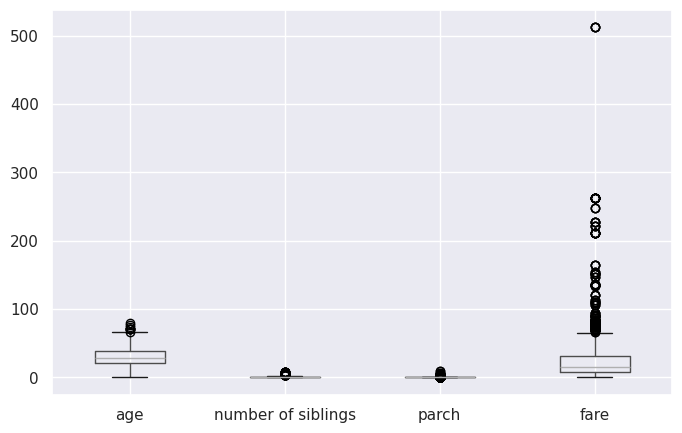

In [27]:
fig, ax = plt.subplots(figsize=(8,5));
titanic_data[data_columns].boxplot();

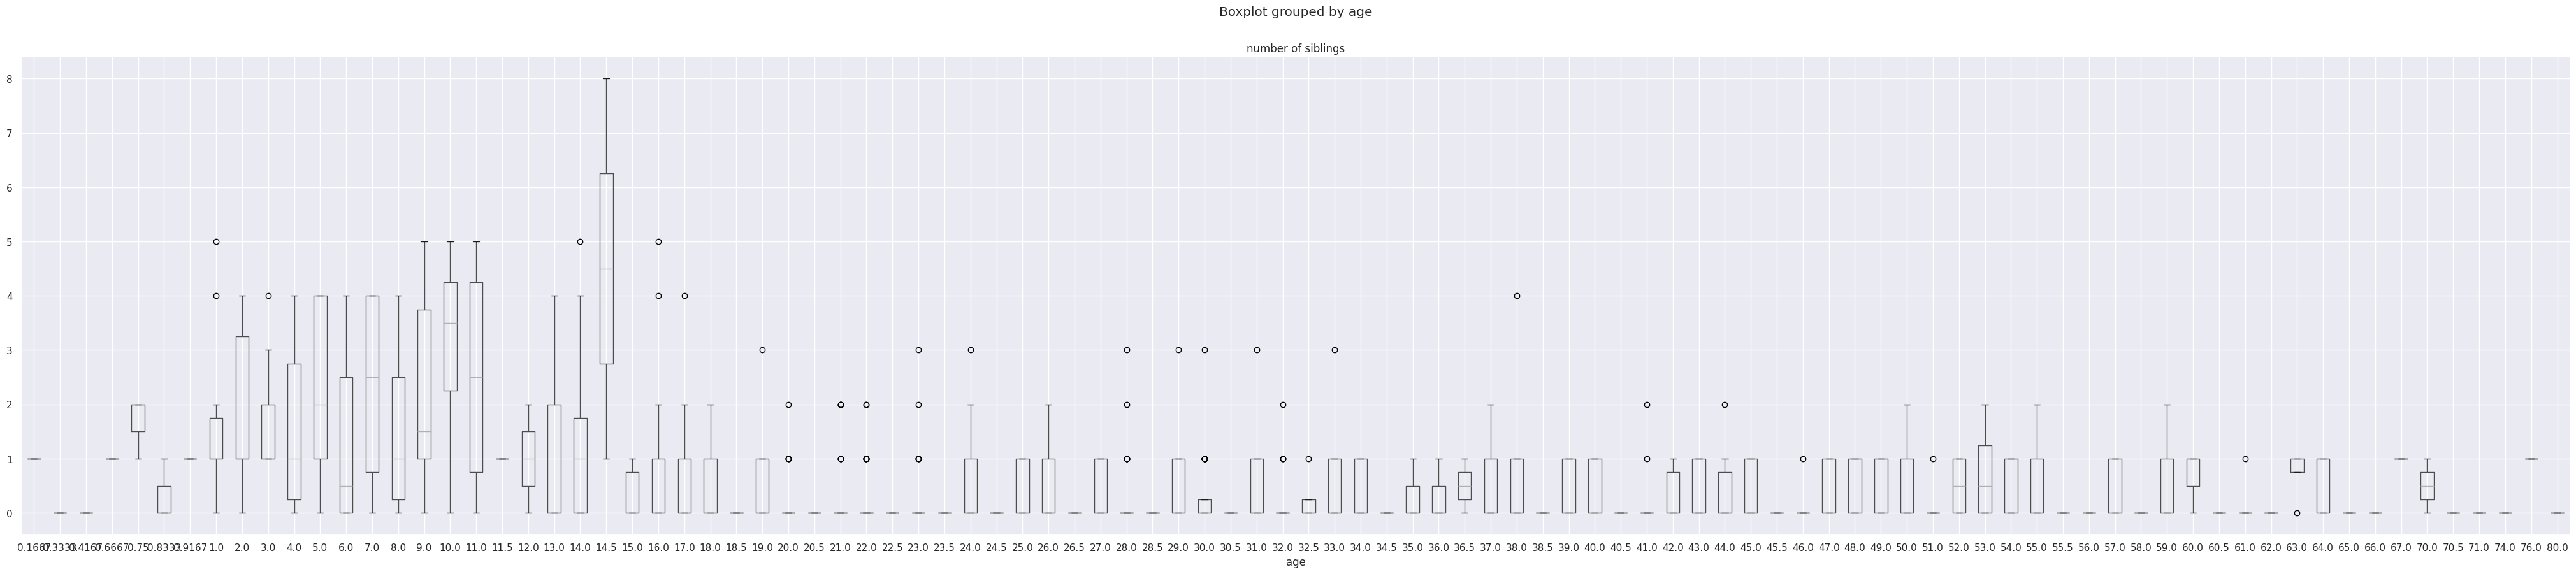

In [28]:
titanic_data.boxplot(column='number of siblings', by='age',figsize=(50,10));
#linea central - mediana
#caja - rango intercuartilico (del 25 al 75%)
#lineas fuera de la caja - valores atípicos

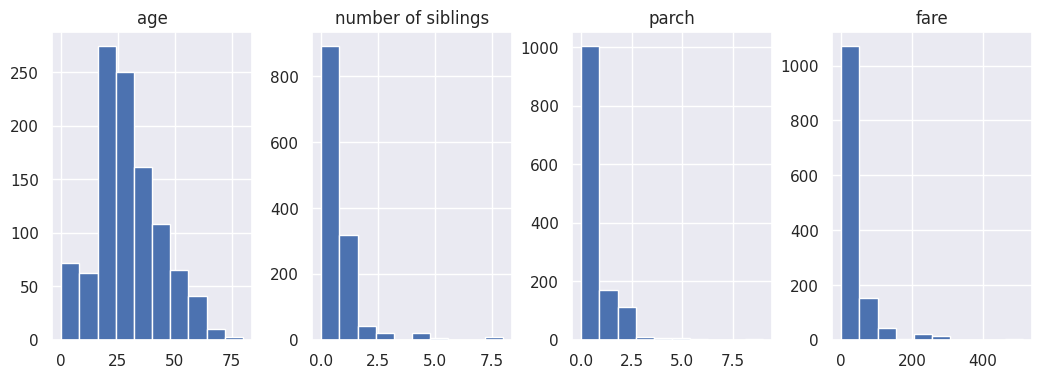

In [29]:
titanic_data[data_columns].hist(figsize=(16,4), layout=(1,5));
#representación simple de los números

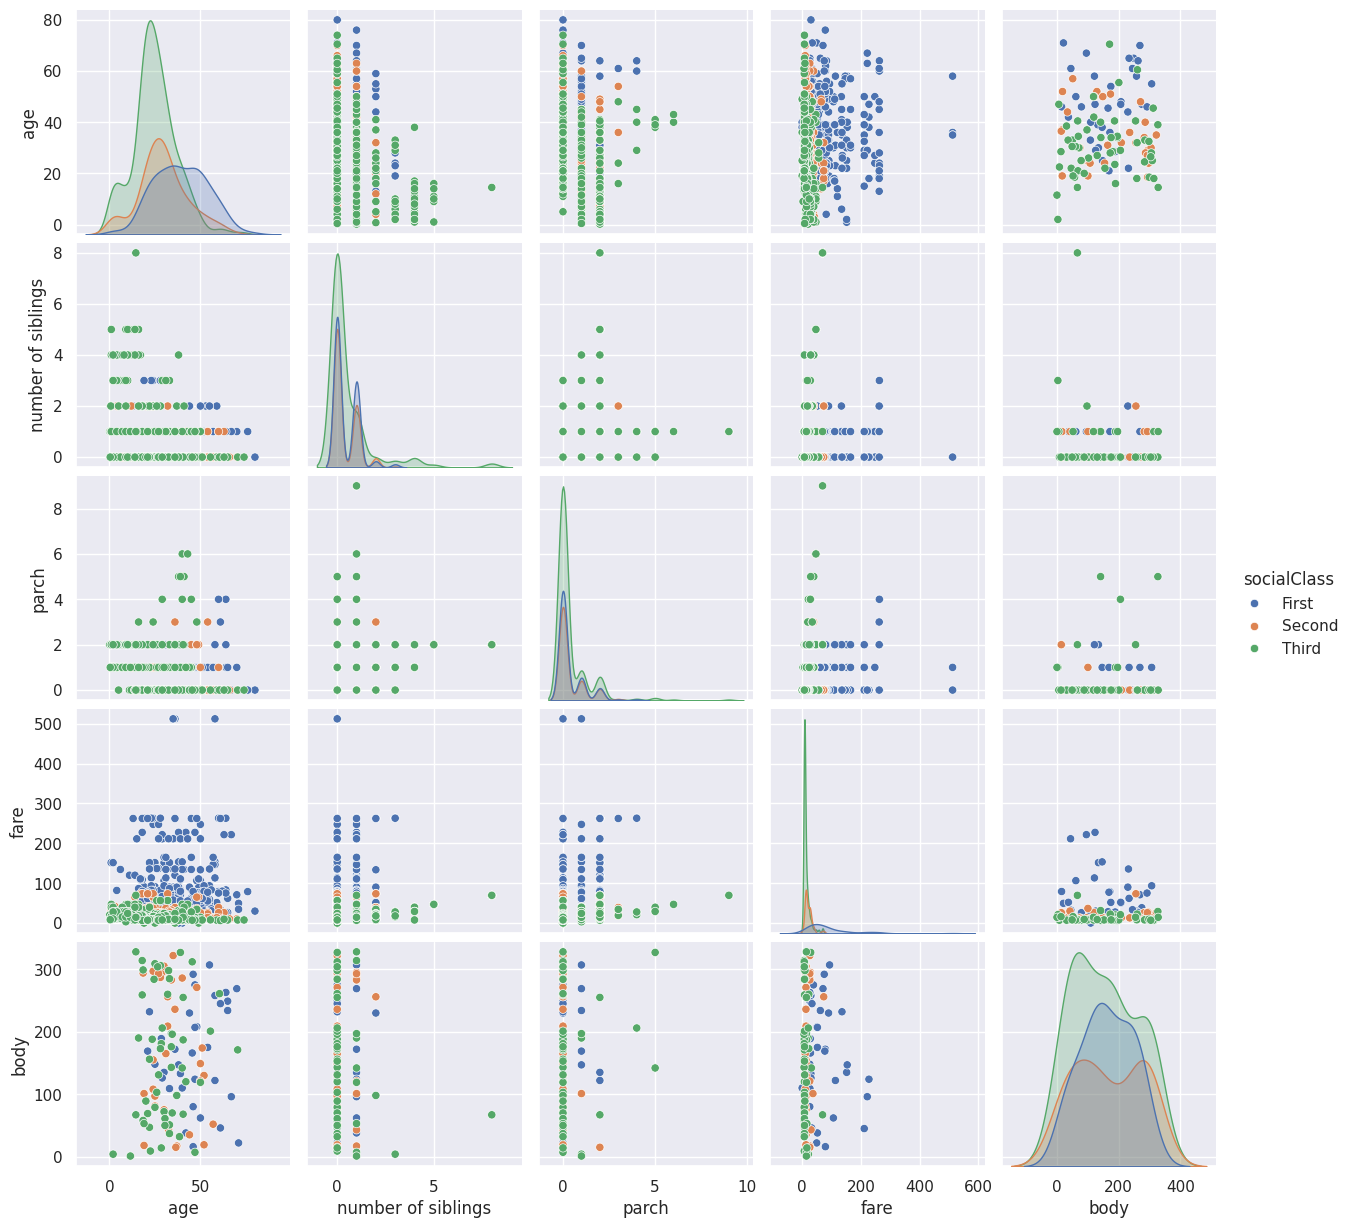

In [30]:
sns.pairplot(titanic_data, hue='socialClass');
# tenemos tres colores representando a cada clase social
# si dos colores están muy mezclados no serán diferenciales

# En este caso las variables están bastante mezcladas. Hará falta un PCA

**1. Aplicar PCA**

In [31]:


# Definimos las columnas numéricas
data_columns = ['age', 'fare', 'number of siblings', 'parch']

# Hacemos una copia del DataFrame original
# Originalmente hacía una copía de las varaibles con valores no nulos.
# Esta vez los rellenaremos usando medias y medianas
titanic_clean = titanic_data.copy()

# Usamos media ya que porque es menos sensible a valores atípicos
imputer = SimpleImputer(strategy='median')

# 4. Rellenamos (los valores nulos
titanic_clean[data_columns] = imputer.fit_transform(titanic_clean[data_columns])

# Estandarizamos los datos: todas las varaibles estarán en el mismo rango, 0 y 1
scaler = StandardScaler()
titanic_standarized = scaler.fit_transform(titanic_clean[data_columns])

# Definimos el PCA
pca = PCA(n_components=2)
pca_results = pca.fit_transform(titanic_standarized)

# Nuevo DataFrame con los resultados
df_pca = pd.DataFrame(data = pca_results, columns = ['PC1', 'PC2'])

# Añadimos las etiquetas
df_pca['socialClass'] = titanic_clean['socialClass'].values
df_pca['survived'] = titanic_clean['survived'].values
df_pca['class'] = titanic_clean['class'].values
#df_pca['class'] = titanic_clean['class'].values

print(f"Pasajeros analizados tras limpiar nulos: {len(df_pca)}")
print("Varianza explicada por cada componente:", pca.explained_variance_ratio_)
df_pca.head()

Pasajeros analizados tras limpiar nulos: 1309
Varianza explicada por cada componente: [0.38623556 0.29579675]


,PC1,PC2,socialClass,survived,class
0,0.677,2.278,First,Yes,First Yes
1,2.878,-0.135,First,Yes,First Yes
2,2.857,-0.073,First,No,First No
3,2.318,1.539,First,No,First No
4,2.414,1.251,First,No,First No


In [32]:
myPCA = PCA().fit(titanic_standarized)

print(myPCA.explained_variance_ratio_)
print(myPCA.explained_variance_ratio_.cumsum())

[0.38623556 0.29579675 0.16312854 0.15483915]
[0.38623556 0.68203231 0.84516085 1.        ]


**-explained_variance_ratio_** (varianza por componente) <br>
una array que muestra el % de información en cada eje del PCA.<br>
PC1: si es muy alto, sobre el 65% significa que una sola combinación de las variables explica la mayor parte de las diferencias entre los pasajeros del tianic<br>
**-explained_variance_ratio_.cumsum() **(varianza acumulada) <br>
suma de los porcentajes anteriores. Ayuda a deducir cuantos porcentajes necesito para visualizar un modelo<br> <br>
Conclusión: si proyectamos en un plano 2D usando únicamente PC1 y PC2 estamos conservando el 70% de la información original (después de la limpieza).

Si usamos 3D ganaríamos un 16% extra de precisión a cambio de una dimensión extra de complejidad

In [36]:
# Transformamos los datos y nos quedamos solo con las 2 primeras columnas
datos_2d = myPCA.transform(titanic_standarized)[:, :2]

# Lo pasamos a un DataFrame para que sea fácil de ver y usar
df_pca = pd.DataFrame(datos_2d, columns=['PC1', 'PC2'])

print(df_pca.head())

     PC1    PC2
0  0.677  2.278
1  2.878 -0.135
2  2.857 -0.073
3  2.318  1.539
4  2.414  1.251


**2. Gráfica de la varianza explicada por cada componente de PCA**

Text(0, 0.5, 'Valores Singulares')

Text(0.5, 0, 'Número de Componente Principal')

Text(0.5, 1.0, 'Gráfico de Sedimentación (Scree Plot) - Datos del Titanic')

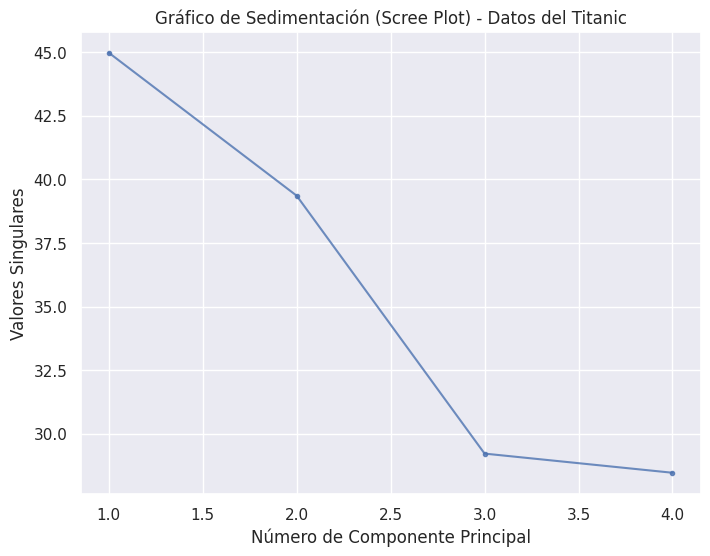

In [38]:
fig = plt.figure(figsize=(8,6))

plt.plot(range(1,len(myPCA.singular_values_)+1), myPCA.singular_values_, alpha=0.8, marker='.')

plt.ylabel('Valores Singulares')
plt.xlabel('Número de Componente Principal') #
plt.title('Gráfico de Sedimentación (Scree Plot) - Datos del Titanic')

# EJE X
#Como el PCA original tien 4 columnas originales, es igual a 4.
# range(1, 5) genera los números entre 1 y 4
# Al ponerlo en primer lugar, el programa sabe que es la X

# EYE Y
# myPCA.singular_values_
# calculo mátematico realizado anteriormente en el PCA. Representa la fuerza/magnitud de cada columna

Teníamos 4 datos diferentes de cada pasajero. Al usar esta técnica hemos logrado 'comprimir' esas 4 variables en solo 2. El gráfico nos demuestra que estas 2 nuevas variables conservan el 95% de la historia original. <br> <br>
Varianza explicada - linea azul
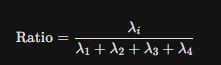<br>
Varianza explicada acumulativa - linea roja
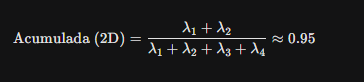

Lambda se consigue buscando un vector que al multiplicarlo por todos nuestros datos no cambie de dirección, solo de tamaño. Esa cantitdad es Lambda<br>
Matemáticamente usariamos la formula del determinante (c-lambda*I)=0

<Figure size 800x600 with 0 Axes>

Text(0.5, 0, 'Número de Componente Principal')

Text(0, 0.5, 'Proporción de Varianza Explicada')

Text(0.5, 1.0, 'Porcentaje de varianza explicada por componente')

([<matplotlib.axis.XTick at 0x7e73681a2570>,
 [Text(1, 0, '1'), Text(2, 0, '2'), Text(3, 0, '3'), Text(4, 0, '4')])

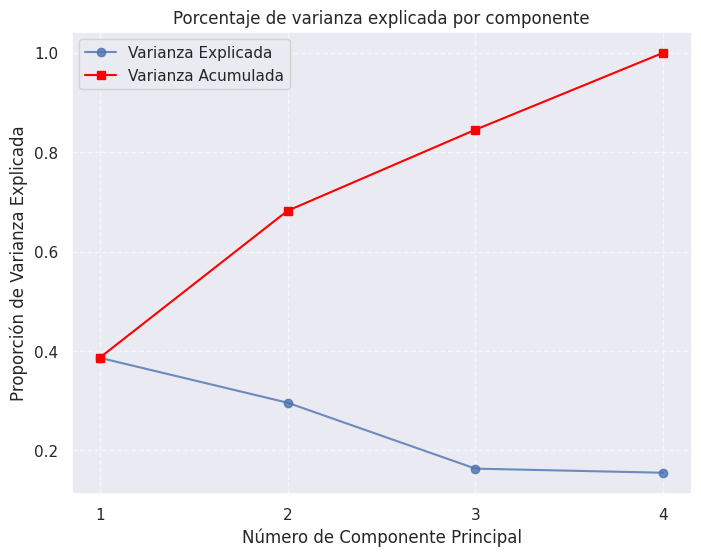

In [40]:

plt.figure(figsize=(8, 6))

# Creamos una lista para el eje X
componentes = range(1, len(myPCA.explained_variance_ratio_) + 1)

# Insertamos la gráfica anterior
plt.plot(componentes, myPCA.explained_variance_ratio_,
         alpha=0.8, marker='o', label="Varianza Explicada")

# Obtenemos la varianza acumulada (versión acumulativa de la explicada)
plt.plot(componentes, np.cumsum(myPCA.explained_variance_ratio_),
         c='red', marker='s', label="Varianza Acumulada")

# Rtiquetas
plt.xlabel('Número de Componente Principal')
plt.ylabel('Proporción de Varianza Explicada')
plt.title('Porcentaje de varianza explicada por componente')

# Extra visual
plt.xticks(componentes)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()



**3. Representar los pesos de los componentes**<br>Visualizamos el peso que asigna nuestro PCA a cada componente

<Figure size 1000x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Peso de las variables originales en PC1 y PC2')

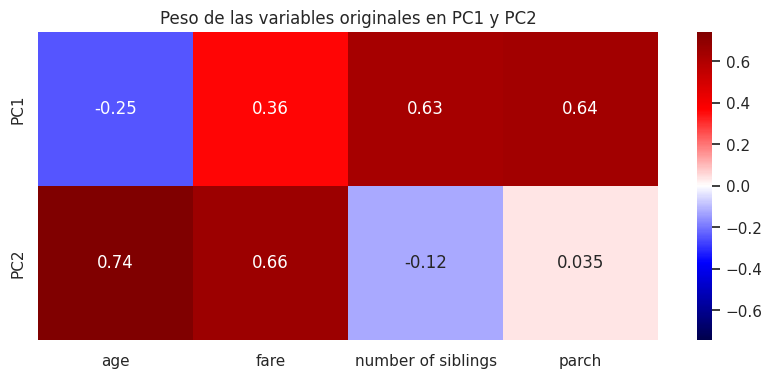

In [41]:
plt.figure(figsize=(10, 4))

# Añadimos [:2, :] para usar solo las dos primeras filas (PC1 y PC2) ya que hemos deducido que PC3 no es representativo
sns.heatmap(myPCA.components_[:2, :],
            cmap='seismic',
            xticklabels=data_columns,
            yticklabels=['PC1', 'PC2'],
            vmin=-np.max(np.abs(myPCA.components_)),
            vmax=np.max(np.abs(myPCA.components_)),
            annot=True)

plt.title('Peso de las variables originales en PC1 y PC2')
plt.show()

#Gráfico que representa el peso de cada variable según PC1 y PC2

**4. Visualizar los datos con PCA en 2/3D:**

Text(0.5, 1.0, 'Distribución de las Clases del Titanic en PC1 y PC2')

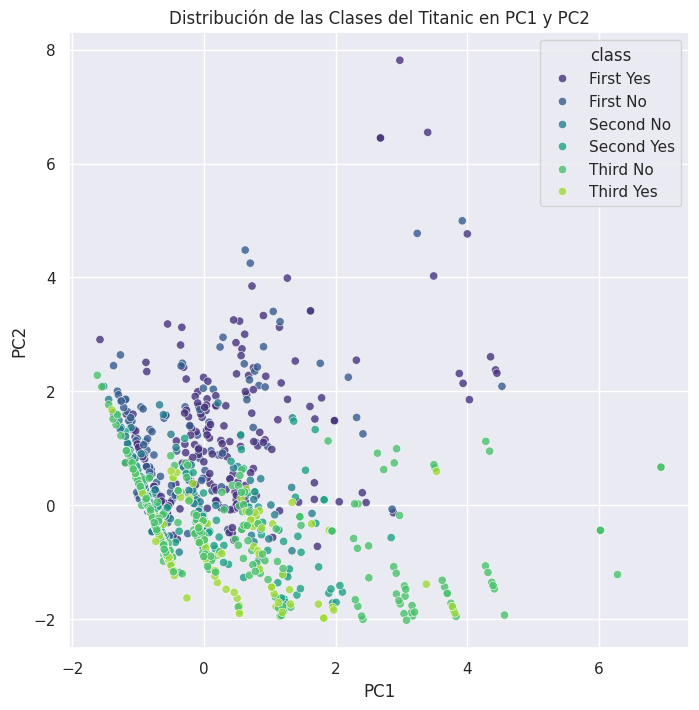

In [42]:
# Transformamos directamente la matriz
transformed_titanic = myPCA.transform(titanic_standarized)

# Guardamos los nuevas componentes en el DataFrame original
titanic_clean['PC1'] = transformed_titanic[:, 0]
titanic_clean['PC2'] = transformed_titanic[:, 1]
titanic_clean['PC3'] = transformed_titanic[:, 2] # No sería necesario. Lo guardamos para visualización 3D y comparar

# Dibujamos el gráfico
fig = plt.figure(figsize=(8,8))
_ = sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='class', # Ahora sí encontrará esta columna
    data=titanic_clean,
    palette='viridis', # Opcional: una paleta bonita para diferenciar clases
    alpha=0.8
)

plt.title('Distribución de las Clases del Titanic en PC1 y PC2')
plt.show()

# La tercera y segunda clase es muy similar
# La primera clase tiene los puntos más dispares
# Tanto los "yes" como los "no" tienen repartidos por todo el gráfico sus valores

Text(0.5, 0, 'PC1')

Text(0.5, 0.5, 'PC2')

Text(0.5, 0, 'PC3')

Text(0.5, 0.92, 'Visualización 3D del Titanic (Matplotlib)')

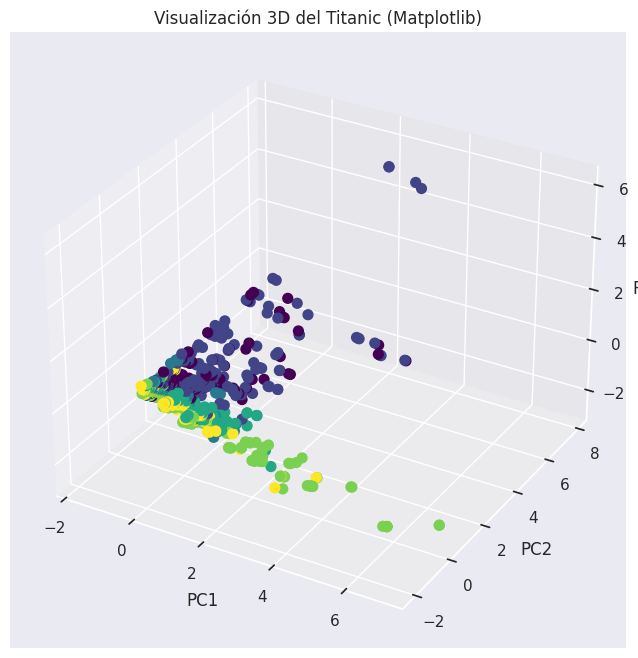

In [46]:


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Convertimos la columna 'class' a código
# Se convertiría en algo tal que
# first no - 0
# first yes - 1 ...
codigos_clase = pd.Categorical(titanic_clean['class']).codes

# Dibujamos los puntos
ax.scatter(
    titanic_clean['PC1'],
    titanic_clean['PC2'],
    titanic_clean['PC3'],
    depthshade=False,
    c=codigos_clase,   # Usamos los códigos que acabamos de generar
    cmap='viridis',
    s=50
)

# Etiquetas
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.title('Visualización 3D del Titanic (Matplotlib)')

plt.show()

In [50]:

# titanic_clean porque ya tiene PC1, PC2, PC3 y 'class'
fig = px.scatter_3d(
    titanic_clean,
    x='PC1',
    y='PC2',
    z='PC3',
    color='class', # Plotly elige paletas de colores muy buenas automáticamente
    title='Visualización 3D Interactiva del Titanic usando PCA',
    opacity=0.8    # Añadimos un poco de transparencia para ver los puntos solapados
)

# modificación visual
fig.update_traces(marker=dict(size=4))


A partir de estas dos gráficas tridimensionales, usando PC1, PC2, PC3, y  las bidimensionales con PC1 y PC2 confirmamos visualmente lo que argumentamos como paso previo al PCA:<br>
- la Primera Clase se separa del resto.<br>
- la tercera dimensión aporta un valor marginal para la segmentación.<br>
Confirmando que un análisis en 2D es suficiente para explicar la varianza principal de nuestros datos (95%).

**5. Aplicar LLE y visualizar los datos en 2/3D**

<Axes: xlabel='LLE1', ylabel='LLE2'>

Text(0.5, 1.0, 'Visualización 2D del Titanic usando LLE (Locally Linear Embedding)')

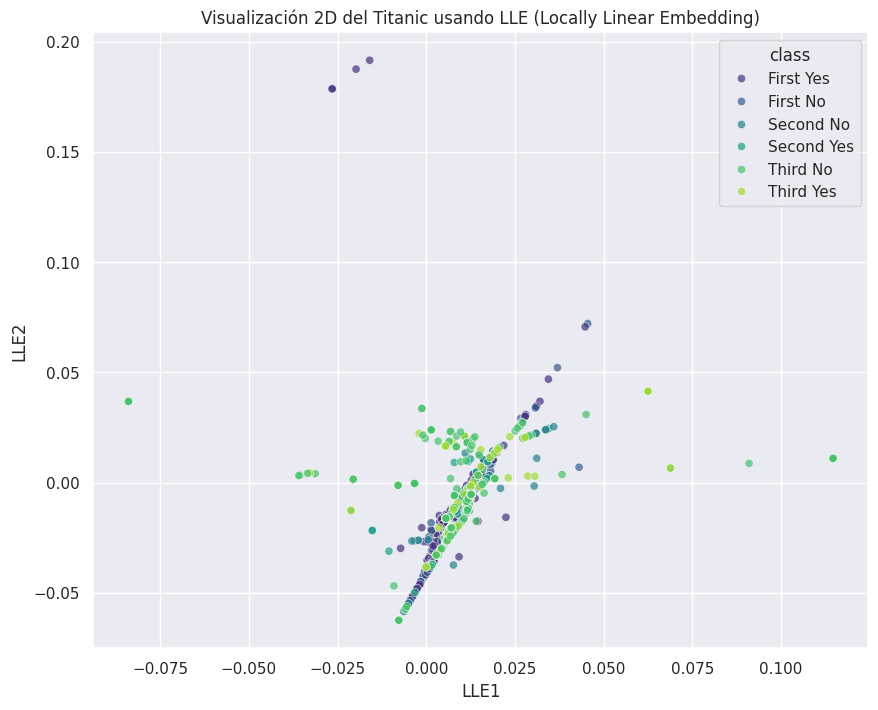

In [53]:

# escalamos los datos entre 0 y 1
titanic_min_max = titanic_clean.copy()
scaler_minmax = MinMaxScaler()
titanic_min_max[data_columns] = scaler_minmax.fit_transform(titanic_clean[data_columns])

# Podemos ver que  los valores min y max son 0 y 1
# print("Resumen de datos tras MinMaxScaler:")
# print(titanic_min_max[data_columns].describe().loc[['min', 'max']])
# print("-" * 50)

# modelo LLE
# n_neighbors=15 número de vecinos más cercanos
lle = LocallyLinearEmbedding(n_components=2, n_neighbors=15, random_state=42)
titanic_lle = lle.fit_transform(titanic_min_max[data_columns])

# Vemos el error de reconstrucción. Cuanto más bajo, mejor
# print(f'Error de reconstrucción LLE: {lle.reconstruction_error_:.4f}')

# nuevas componentes LLE.
# mostramos
titanic_min_max[['LLE1', 'LLE2']] = titanic_lle

fig = plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='LLE1',
    y='LLE2',
    hue='class',
    data=titanic_min_max,
    palette='viridis',
    alpha=0.7
)

plt.title('Visualización 2D del Titanic usando LLE (Locally Linear Embedding)')

Text(0.5, 0, 'LLE1')

Text(0.5, 0.5, 'LLE2')

Text(0.5, 0, 'LLE3')

Text(0.5, 0.92, 'Visualización 3D del Titanic usando LLE')

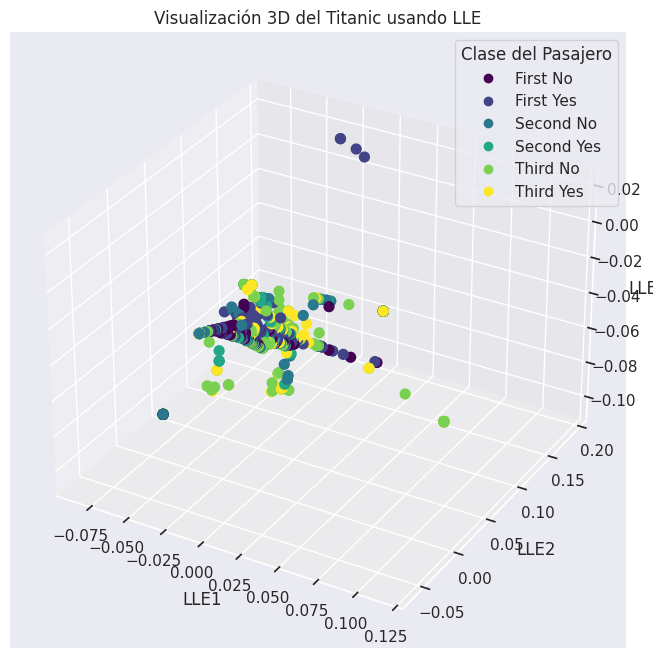

In [55]:


# LLE para 3 Dimensiones
lle_3d = LocallyLinearEmbedding(n_components=3, n_neighbors=15, random_state=42)

# transformamos los datos
titanic_lle_3d = lle_3d.fit_transform(titanic_min_max[data_columns])

# Comprobamos si el error ha bajado
# print(f'Error de reconstrucción LLE (3D): {lle_3d.reconstruction_error_:.4f}')

# Guardamos las 3 nuevas coordenadas
titanic_min_max[['LLE1', 'LLE2', 'LLE3']] = titanic_lle_3d

# modificaicones visaules
categoria_clase = pd.Categorical(titanic_min_max['class'])
codigos_clase = categoria_clase.codes
nombres_clase = categoria_clase.categories

# mostramos
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    titanic_min_max['LLE1'],
    titanic_min_max['LLE2'],
    titanic_min_max['LLE3'],
    depthshade=False,
    c=codigos_clase,
    cmap='viridis',
    s=50
)

# leyenda y etiquetas
handles, _ = scatter.legend_elements()
ax.legend(handles, nombres_clase, title="Clase del Pasajero")

ax.set_xlabel('LLE1')
ax.set_ylabel('LLE2')
ax.set_zlabel('LLE3')
plt.title('Visualización 3D del Titanic usando LLE')



In [57]:

# Repetimos el proceso para un gráfico interactivo...

pca_3d = PCA(n_components=3, random_state=42)
pca_features = pca_3d.fit_transform(titanic_standarized)

df_pca_3d = pd.DataFrame(pca_features, columns=['PC1', 'PC2', 'PC3'])


df_pca_3d['class'] = titanic_clean['class'].values


fig = px.scatter_3d(
    df_pca_3d,
    x='PC1',
    y='PC2',
    z='PC3',
    color='class',
    title='Visualización 3D interactiva del Titanic usando PCA',
    opacity=0.8 # Un poco de transparencia para ver los puntos solapados
)

# Hacemos los puntos un poco más precisos
fig.update_traces(marker=dict(size=4))



**6. Aplicar t-SNE y visualizar los datos en 2/3D**

<Axes: xlabel='TSNE1', ylabel='TSNE2'>

Text(0.5, 1.0, 'Visualización 2D del Titanic usando t-SNE')

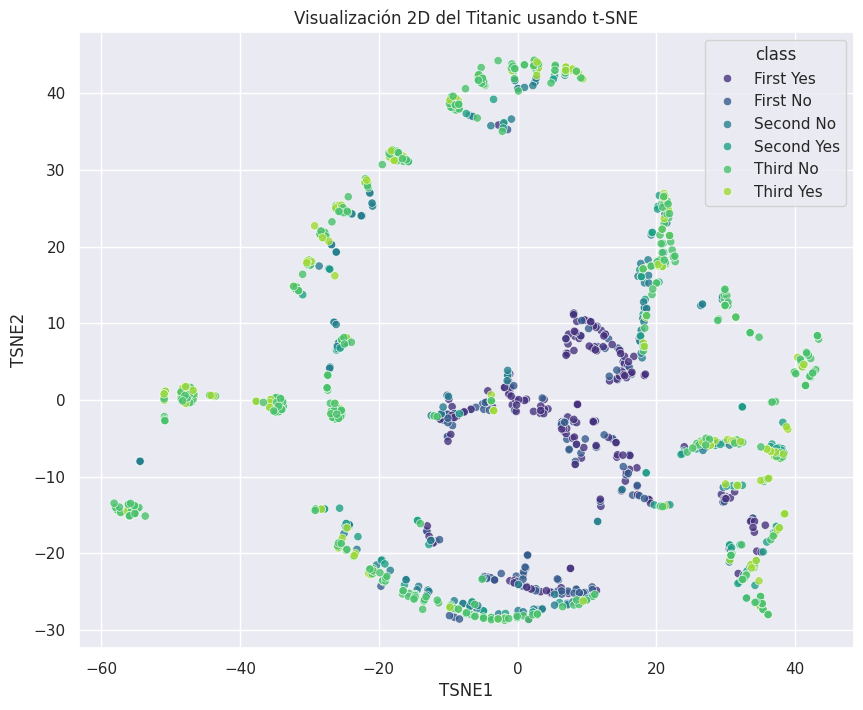

In [58]:


# Definimos algoritmo t-SNE
tsne = TSNE(n_components=2, perplexity=30, init='random', random_state=42)

# Transformamos los datos usando la matriz estandarizada original
titanic_tsne = tsne.fit_transform(titanic_standarized)

# Guardamos las nuevas coordenadas
titanic_clean[['TSNE1', 'TSNE2']] = titanic_tsne

# mostramos
fig = plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='TSNE1',
    y='TSNE2',
    hue='class',
    data=titanic_clean,
    palette='viridis',
    alpha=0.8
)

plt.title('Visualización 2D del Titanic usando t-SNE')
plt.show()

Text(0.5, 0, 'TSNE1')

Text(0.5, 0.5, 'TSNE2')

Text(0.5, 0, 'TSNE3')

Text(0.5, 0.92, 'Visualización 3D del Titanic usando t-SNE')

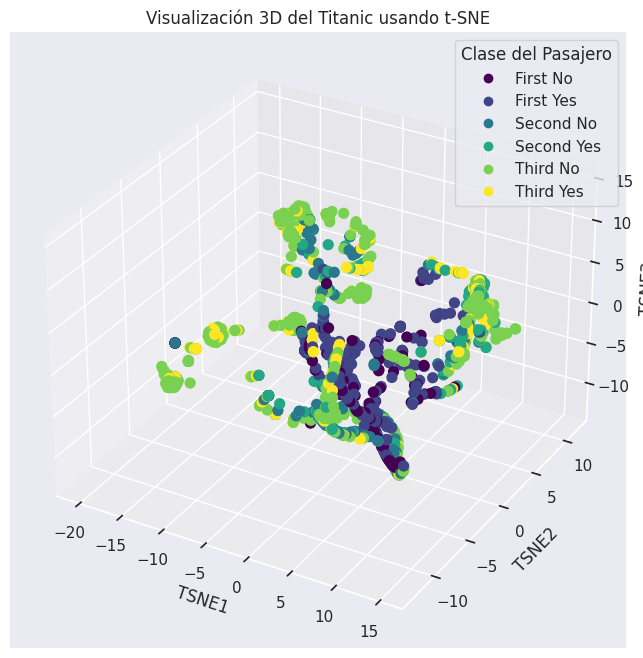

In [59]:
# Repetimos para 3 dimensiones ...
tsne_3d = TSNE(n_components=3, perplexity=30, init='random', random_state=42)

titanic_tsne_3d = tsne_3d.fit_transform(titanic_standarized)

titanic_clean[['TSNE1', 'TSNE2', 'TSNE3']] = titanic_tsne_3d


categoria_clase = pd.Categorical(titanic_clean['class'])
codigos_clase = categoria_clase.codes
nombres_clase = categoria_clase.categories

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    titanic_clean['TSNE1'],
    titanic_clean['TSNE2'],
    titanic_clean['TSNE3'],
    depthshade=False,
    c=codigos_clase,
    cmap='viridis',
    s=50
)


handles, _ = scatter.legend_elements()
ax.legend(handles, nombres_clase, title="Clase del Pasajero")

ax.set_xlabel('TSNE1')
ax.set_ylabel('TSNE2')
ax.set_zlabel('TSNE3')
plt.title('Visualización 3D del Titanic usando t-SNE')

plt.show()

In [61]:
# repetimos para 3 dimensiones interactivas...
fig = px.scatter_3d(
    titanic_clean,
    x='TSNE1',
    y='TSNE2',
    z='TSNE3',
    color='class',
    title='Visualización 3D interactiva del Titanic usando t-SNE',
    opacity=0.8 # Transparencia para ver a través de los puntos
)

fig.update_traces(marker=dict(size=4))



Datos entre 0 y 1

<Axes: xlabel='TSNE1', ylabel='TSNE2'>

Text(0.5, 1.0, 't-SNE 2D del Titanic (Usando escalado MinMaxScaler 0-1)')

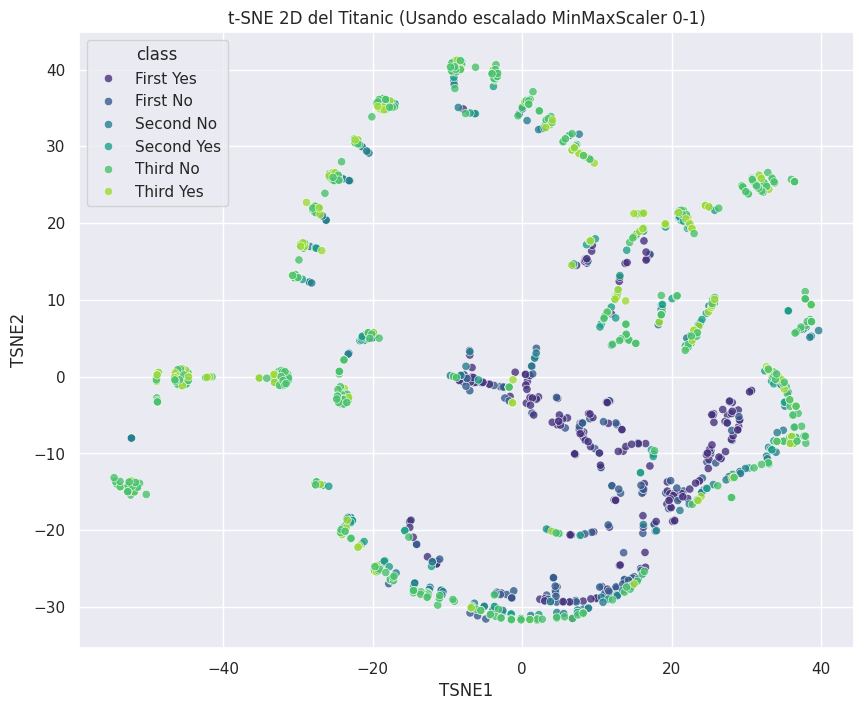

In [62]:

# t-SNE
tsne_minmax = TSNE(n_components=2, perplexity=30, init='random', random_state=42)

# titanic_min_max en lugar de titanic_standarized
titanic_tsne_minmax = tsne_minmax.fit_transform(titanic_min_max[data_columns])

# nuevas coordenadas
titanic_min_max[['TSNE1', 'TSNE2']] = titanic_tsne_minmax

# mostramos
fig = plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='TSNE1',
    y='TSNE2',
    hue='class',
    data=titanic_min_max,
    palette='viridis',
    alpha=0.8
)

plt.title('t-SNE 2D del Titanic (Usando escalado MinMaxScaler 0-1)')
plt.show()

Text(0.5, 0, 'TSNE1')

Text(0.5, 0.5, 'TSNE2')

Text(0.5, 0, 'TSNE3')

Text(0.5, 0.92, 't-SNE 3D del Titanic (Estático con MinMaxScaler)')

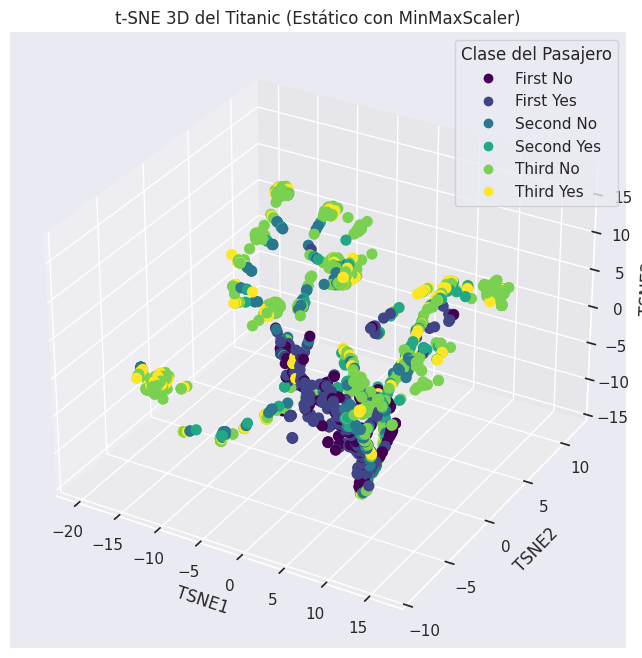

In [64]:
# repetimos para el gráfico en 3D....

tsne_minmax_3d = TSNE(n_components=3, perplexity=30, init='random', random_state=42)


titanic_tsne_minmax_3d = tsne_minmax_3d.fit_transform(titanic_min_max[data_columns])


titanic_min_max[['TSNE1', 'TSNE2', 'TSNE3']] = titanic_tsne_minmax_3d

categoria_clase = pd.Categorical(titanic_min_max['class'])
codigos_clase = categoria_clase.codes
nombres_clase = categoria_clase.categories

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    titanic_min_max['TSNE1'],
    titanic_min_max['TSNE2'],
    titanic_min_max['TSNE3'],
    depthshade=False,
    c=codigos_clase,
    cmap='viridis',
    s=50
)

handles, _ = scatter.legend_elements()
ax.legend(handles, nombres_clase, title="Clase del Pasajero")

ax.set_xlabel('TSNE1')
ax.set_ylabel('TSNE2')
ax.set_zlabel('TSNE3')
plt.title('t-SNE 3D del Titanic (Estático con MinMaxScaler)')

plt.show()

In [66]:
# repetimos para el gráfico en 3D interactivo....

fig = px.scatter_3d(
    titanic_min_max,
    x='TSNE1',
    y='TSNE2',
    z='TSNE3',
    color='class',
    title='t-SNE 3D Interactivo del Titanic (Plotly con MinMaxScaler)',
    opacity=0.8
)

fig.update_traces(marker=dict(size=4))


Standard scaler (distancias)

<Axes: xlabel='TSNE1_std', ylabel='TSNE2_std'>

Text(0.5, 1.0, 't-SNE 2D del Titanic (Usando StandardScaler)')

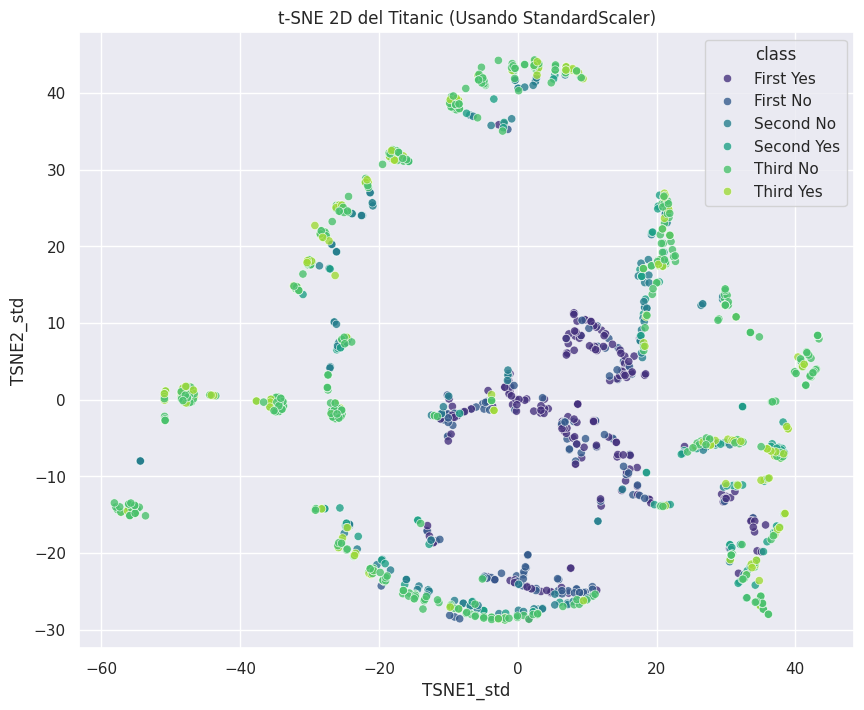

In [67]:
# t-SNE
tsne_std_2d = TSNE(n_components=2, perplexity=30, init='random', random_state=42)

# transofmramos usando la matriz estandarizada
titanic_tsne_std_2d = tsne_std_2d.fit_transform(titanic_standarized)

# guardamos las nuevas coordenadas
titanic_clean[['TSNE1_std', 'TSNE2_std']] = titanic_tsne_std_2d

# mostramos
fig = plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='TSNE1_std',
    y='TSNE2_std',
    hue='class',
    data=titanic_clean,
    palette='viridis',
    alpha=0.8
)

plt.title('t-SNE 2D del Titanic (Usando StandardScaler)')
plt.show()

Text(0.5, 0, 'TSNE1_std')

Text(0.5, 0.5, 'TSNE2_std')

Text(0.5, 0, 'TSNE3_std')

Text(0.5, 0.92, 't-SNE 3D del Titanic (Estático con StandardScaler)')

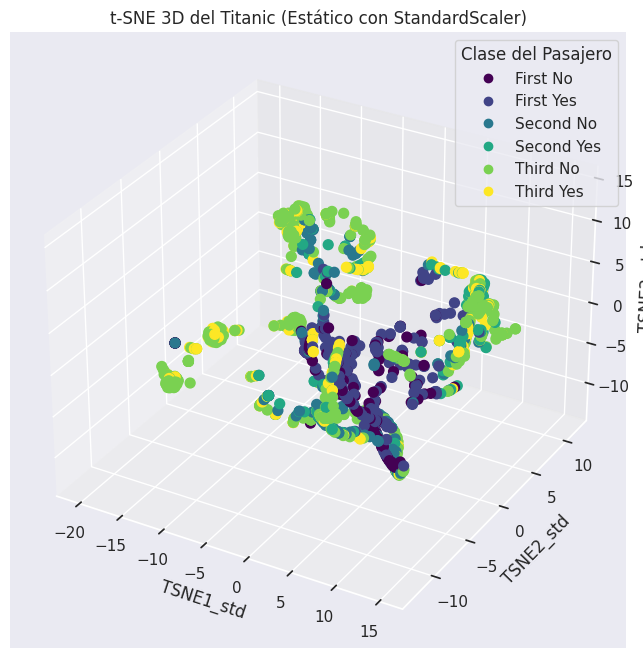

In [68]:
# repetimos el paso usando 3 dimensiones...
tsne_std_3d = TSNE(n_components=3, perplexity=30, init='random', random_state=42)


titanic_tsne_std_3d = tsne_std_3d.fit_transform(titanic_standarized)

titanic_clean[['TSNE1_std_3D', 'TSNE2_std_3D', 'TSNE3_std_3D']] = titanic_tsne_std_3d


categoria_clase = pd.Categorical(titanic_clean['class'])
codigos_clase = categoria_clase.codes
nombres_clase = categoria_clase.categories


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    titanic_clean['TSNE1_std_3D'],
    titanic_clean['TSNE2_std_3D'],
    titanic_clean['TSNE3_std_3D'],
    depthshade=False,
    c=codigos_clase,
    cmap='viridis',
    s=50
)


handles, _ = scatter.legend_elements()
ax.legend(handles, nombres_clase, title="Clase del Pasajero")

ax.set_xlabel('TSNE1_std')
ax.set_ylabel('TSNE2_std')
ax.set_zlabel('TSNE3_std')
plt.title('t-SNE 3D del Titanic (Estático con StandardScaler)')

plt.show()

In [69]:
# repetimos el paso para 3 dimensiones interactivas ...
fig = px.scatter_3d(
    titanic_clean,
    x='TSNE1_std_3D',
    y='TSNE2_std_3D',
    z='TSNE3_std_3D',
    color='class',
    title='t-SNE 3D Interactivo del Titanic (Plotly con StandardScaler)',
    opacity=0.8
)

fig.update_traces(marker=dict(size=4))

fig.show()

Con PCA

<Axes: xlabel='TSNE1_pca', ylabel='TSNE2_pca'>

Text(0.5, 1.0, 't-SNE 2D del Titanic (Inicialización con PCA)')

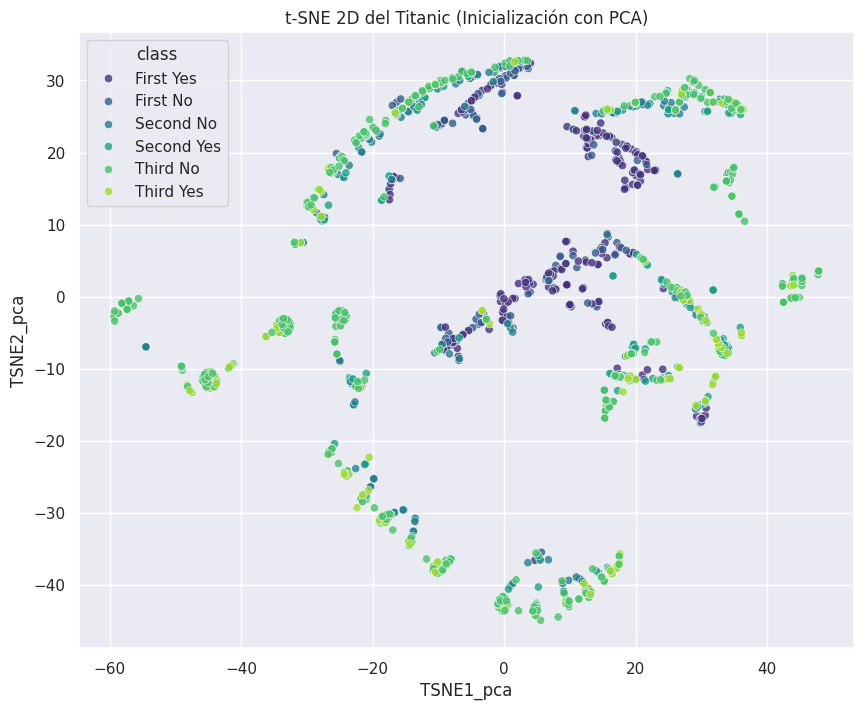

In [70]:

# t-SNE usando init='pca'
# perplexity=30 y quitamos n_iter por compatibilidad
tsne_pca_2d = TSNE(n_components=2, perplexity=30, init='pca', random_state=42)

# modificamos los datos estandarizados
titanic_tsne_pca_2d = tsne_pca_2d.fit_transform(titanic_standarized)

# coordenadas
titanic_clean[['TSNE1_pca', 'TSNE2_pca']] = titanic_tsne_pca_2d

# mostramos
fig = plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='TSNE1_pca',
    y='TSNE2_pca',
    hue='class',
    data=titanic_clean,
    palette='viridis',
    alpha=0.8
)

plt.title('t-SNE 2D del Titanic (Inicialización con PCA)')
plt.show()

Text(0.5, 0, 'TSNE1_pca')

Text(0.5, 0.5, 'TSNE2_pca')

Text(0.5, 0, 'TSNE3_pca')

Text(0.5, 0.92, 't-SNE 3D del Titanic (Estático con init=PCA)')

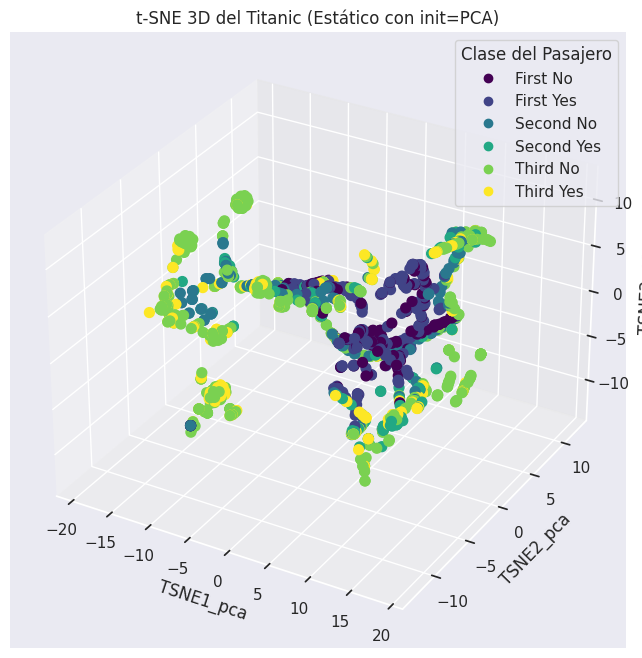

In [71]:
# repetimos en 3D...
tsne_pca_3d = TSNE(n_components=3, perplexity=30, init='pca', random_state=42)

titanic_tsne_pca_3d = tsne_pca_3d.fit_transform(titanic_standarized)

titanic_clean[['TSNE1_pca_3D', 'TSNE2_pca_3D', 'TSNE3_pca_3D']] = titanic_tsne_pca_3d

categoria_clase = pd.Categorical(titanic_clean['class'])
codigos_clase = categoria_clase.codes
nombres_clase = categoria_clase.categories

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    titanic_clean['TSNE1_pca_3D'],
    titanic_clean['TSNE2_pca_3D'],
    titanic_clean['TSNE3_pca_3D'],
    depthshade=False,
    c=codigos_clase,
    cmap='viridis',
    s=50
)

handles, _ = scatter.legend_elements()
ax.legend(handles, nombres_clase, title="Clase del Pasajero")

ax.set_xlabel('TSNE1_pca')
ax.set_ylabel('TSNE2_pca')
ax.set_zlabel('TSNE3_pca')
plt.title('t-SNE 3D del Titanic (Estático con init=PCA)')

plt.show()

In [72]:
# repetimos en 3D interactivo...
fig = px.scatter_3d(
    titanic_clean,
    x='TSNE1_pca_3D',
    y='TSNE2_pca_3D',
    z='TSNE3_pca_3D',
    color='class',
    title='t-SNE 3D Interactivo del Titanic (Plotly con init=PCA)',
    opacity=0.8
)

fig.update_traces(marker=dict(size=4))

fig.show()